# Stage 1B.2: Structured Internal Transformation and the Concentration Regime

Stage 1B.2 investigates whether nonlinear oscillator dynamics, evolved over topologies learned from image populations, produce **structured internal transformations**. Unlike earlier stages that focused on static features or infinitesimal responses, Stage 1B.2 uses finite-amplitude perturbations along baseline trajectories to determine if the resulting state changes are reproducible and input-sensitive. This notebook walks through a key discovery from this stage: the **concentration regime**, where energy from a local perturbation relocates onto specific, deterministic destination nodes rather than spreading broadly across the network.


In [20]:
import pickle
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kruskal

# Setup imports from local directory
THIS_DIR = Path(".").resolve()
sys.path.insert(0, str(THIS_DIR))

from bonsai.data.mnist_loader import load_mnist
from bonsai.dynamics.learned_topology_construction import build_class_topology
from stage1b2_core import get_degree_stratified_nodes

# Paths to cached results
RESULTS_DIR = THIS_DIR / "results"
RESULTS_PATH = RESULTS_DIR / "stage1b2_results.pkl"
FINAL_ANALYSIS_PATH = RESULTS_DIR / "stage1b2_final_analysis.pkl"
CONSTRUCTIONS_PATH = RESULTS_DIR / "class0_constructions.pkl"
KMNIST_DIR = THIS_DIR / "../../datasets/kmnist"

# Constants for mapping factor levels to ranks
AMPLITUDE_RANK = {0.025: 1, 0.2: 2, 0.8: 3}
TP_RANK = {0: 1, 0.833: 2, 1.667: 3, 2.5: 4}

print("Environment initialized and paths set.")


Environment initialized and paths set.


## 1. Data Loading and Concentration Metrics

We start by loading the 432 trials from Stage 1B.2. For each trial, we compute measures of energy concentration:
- **top1**: The fraction of energy held by the single largest node.
- **effective_n**: The inverse participation ratio ($1 / \sum q_i^2$), representing the "effective number" of participating nodes. Smaller values indicate higher concentration.


In [21]:
def load_and_process_results():
    with open(RESULTS_PATH, "rb") as f:
        results = pickle.load(f)
    
    with open(CONSTRUCTIONS_PATH, "rb") as f:
        constructions = pickle.load(f)[0]
    W = constructions["constructions"]["T"]
    node_lookup = get_degree_stratified_nodes(W)

    rows = []
    for (t_p, replica, node_label, sign, amplitude), trial in results.items():
        q = np.asarray(trial["fixed_time_q"])
        sorted_q = np.sort(q)[::-1]
        top1 = float(sorted_q[0])
        ipr = float(np.sum(q ** 2))
        effective_n = 1.0 / ipr
        argmax_node = int(np.argmax(q))
        stimulated_node = node_lookup[node_label]
        
        rows.append({
            "t_p": t_p, "replica": replica, "node_label": node_label, "sign": sign,
            "amplitude": amplitude, "top1": top1, "effective_n": effective_n,
            "argmax_node": argmax_node, "stimulated_node": stimulated_node,
            "argmax_is_source": argmax_node == stimulated_node,
        })
    return pd.DataFrame(rows), node_lookup

df, node_lookup = load_and_process_results()
print(f"Loaded {len(df)} trials.")
df.head()


Loaded 432 trials.


,t_p,replica,node_label,sign,amplitude,top1,effective_n,argmax_node,stimulated_node,argmax_is_source
0,0.0,0,low,-1,0.025,0.343941,5.719084,17,17,True
1,0.0,0,low,-1,0.800,0.414967,4.430247,17,17,True
2,0.0,0,low,1,0.200,0.334793,5.914191,17,17,True
3,0.0,0,median,1,0.200,0.090465,20.258169,363,363,True
4,0.0,0,low,1,0.800,0.319286,6.276596,17,17,True


## 2. Amplitude and Sign: A Null Result for Concentration

We first check if the magnitude of the perturbation (amplitude) or its direction (sign) drives the energy concentration. Using Spearman rank correlations and Kruskal-Wallis tests, we find that these factors have little to no systematic effect on the overall concentration level across the full dataset.


In [22]:
# Factor rank mapping
df['amp_rank'] = df['amplitude'].map(AMPLITUDE_RANK)
df['tp_rank'] = df['t_p'].map(TP_RANK)

print("-- Spearman rank correlations --")
for factor in ["amplitude", "t_p"]:
    rank_col = "amp_rank" if factor == "amplitude" else "tp_rank"
    rho, p = spearmanr(df[rank_col], df["top1"])
    print(f"  {factor} vs top1: rho={rho:+.3f}, p={p:.5f}")

print("\n-- Kruskal-Wallis tests --")
for factor in ["amplitude", "sign"]:
    groups = [group["top1"].values for name, group in df.groupby(factor)]
    stat, p = kruskal(*groups)
    print(f"  top1 across {factor} levels: H={stat:.3f}, p={p:.5f}")


-- Spearman rank correlations --
  amplitude vs top1: rho=-0.019, p=0.69608
  t_p vs top1: rho=-0.236, p=0.00000

-- Kruskal-Wallis tests --
  top1 across amplitude levels: H=0.154, p=0.92574
  top1 across sign levels: H=0.007, p=0.93428


## 3. The $t_p \times$ Node Interaction

While amplitude and sign show no global effect, energy concentration is highly sensitive to **when** the perturbation occurs ($t_p$) and **which node** is stimulated. The table below shows the fraction of "highly concentrated" trials (top1 > 0.5) for each $t_p \times$ amplitude cell. Note the striking concentration at $t_p=0$ for certain amplitudes, which we will investigate further.


In [23]:
print('-- Fraction of trials with top1 > 0.5 (highly concentrated) by (t_p, amplitude) --')
ctab = df.groupby(['t_p', 'amplitude'])['top1'].apply(lambda x: (x > 0.5).mean()).unstack()
ctab.columns = [f'amp={a}' for a in ctab.columns]
ctab.index = [f't_p={t}' for t in ctab.index]
display(ctab)

print()
print('CAUTION: this table pools all three stimulated-node types (low/median/high degree)')
print('together at each (t_p, amplitude) cell. It genuinely understates the effect -- e.g.')
print('the 0.333 at (t_p=0, amp=0.025) is 12 concentrated trials out of 36 in that cell, but')
print('those 12 are ALL 12 high-degree-node trials (both signs x 6 replicas = 12/12), while')
print('the low- and median-degree nodes contribute 0 concentrated trials out of the other 24.')
print('Section 4 isolates the high-degree node specifically and shows the true, sharp pattern:')
print('not a modest ~33% rate, but a clean, deterministic split within that one node/time cell.')

-- Fraction of trials with top1 > 0.5 (highly concentrated) by (t_p, amplitude) --


,amp=0.025,amp=0.2,amp=0.8
t_p=0.0,0.333333,0.166667,0.166667
t_p=0.833,0.000000,0.000000,0.000000
t_p=1.667,0.000000,0.000000,0.000000
t_p=2.5,0.000000,0.000000,0.000000



CAUTION: this table pools all three stimulated-node types (low/median/high degree)
together at each (t_p, amplitude) cell. It genuinely understates the effect -- e.g.
the 0.333 at (t_p=0, amp=0.025) is 12 concentrated trials out of 36 in that cell, but
those 12 are ALL 12 high-degree-node trials (both signs x 6 replicas = 12/12), while
the low- and median-degree nodes contribute 0 concentrated trials out of the other 24.
Section 4 isolates the high-degree node specifically and shows the true, sharp pattern:
not a modest ~33% rate, but a clean, deterministic split within that one node/time cell.


## 4. The 4-of-6 Deterministic Breakdown

Focusing on the high-degree node at $t_p=0$, we discover a precise, deterministic pattern. Concentration (top1 > 0.5) occurs in 4 out of the 6 (sign, amplitude) conditions, and in those cases, it is **perfectly uniform** across all 6 replicas. In these trials, the energy relocates from the source node to one of two specific destination nodes (indices 103 or 152).


In [24]:
cell_mask = (df['t_p'] == 0) & (df['node_label'] == 'high')
cell_df = df[cell_mask].copy()
stim_node = node_lookup['high']

print(f"High-degree stimulated node index: {stim_node}")
print(f"Dominant node is ever the stimulated node itself: {cell_df['argmax_is_source'].any()}")

summary = []
for (sign, amp), group in cell_df.groupby(['sign', 'amplitude']):
    dests = set(group['argmax_node'])
    n_conc = (group['top1'] > 0.5).sum()
    summary.append({
        'sign': sign, 'amplitude': amp, 'destinations': dests,
        'concentrated': f"{n_conc}/6",
        'top1_range': f"[{group['top1'].min():.3f}, {group['top1'].max():.3f}]"
    })

pd.DataFrame(summary)


High-degree stimulated node index: 129
Dominant node is ever the stimulated node itself: False


,sign,amplitude,destinations,concentrated,top1_range
0,-1,0.025,{103},6/6,"[0.616, 0.670]"
1,-1,0.200,{103},0/6,"[0.387, 0.446]"
2,-1,0.800,{152},0/6,"[0.181, 0.188]"
3,1,0.025,{103},6/6,"[0.671, 0.720]"
4,1,0.200,{103},6/6,"[0.818, 0.851]"
5,1,0.800,{103},6/6,"[0.976, 0.976]"


## 5. Visualizing the Concentration: Sign $\times$ Amplitude Grid

This grid shows which combinations of sign and amplitude result in a concentrated response for the high-degree node at $t_p=0$. The pattern is perfectly binary (4 concentrated, 2 not).


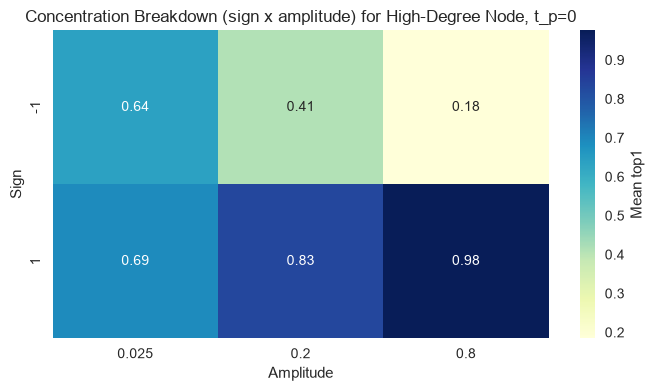

In [25]:
grid_data = cell_df.groupby(['sign', 'amplitude'])['top1'].mean().unstack()
plt.figure(figsize=(8, 4))
sns.heatmap(grid_data, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Mean top1'})
plt.title("Concentration Breakdown (sign x amplitude) for High-Degree Node, t_p=0")
plt.ylabel("Sign")
plt.xlabel("Amplitude")
plt.show()


## 6. Topology Visualization: The Routing Grid

To understand where the energy is going, we visualize the KMNIST class-0 active pixel grid. We mark the high-degree source node and the two destination nodes (103, 152) at their actual positions in the 28x28 grid.


Verified: rebuilt T matches cached T (max abs diff = 2.22e-16)


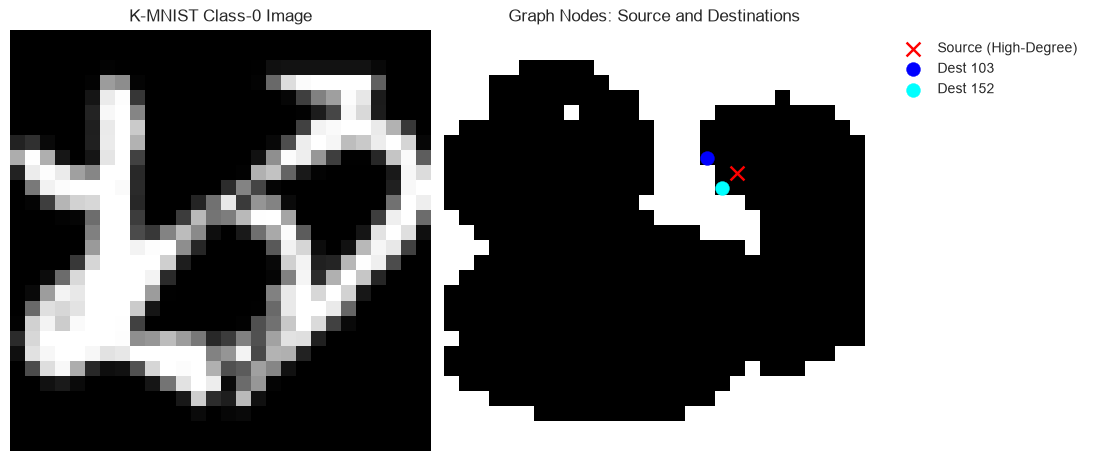

In [26]:
# 1. Reconstruct active_indices for Class 0
X_train, y_train, _, _ = load_mnist(str(KMNIST_DIR), gz=False)
idx = np.where(y_train == 0)[0][:200]
images = X_train[idx].astype(np.float64) / 255.0
active_indices, T_rebuilt = build_class_topology(images)

# Verify the reconstruction matches the cached, already-verified T before trusting node positions below
with open(CONSTRUCTIONS_PATH, 'rb') as f:
    _constructions_check = pickle.load(f)[0]
T_cached = _constructions_check['constructions']['T']
assert np.allclose(T_rebuilt, T_cached), 'Rebuilt T does not match cached T -- node positions below would be wrong'
print(f'Verified: rebuilt T matches cached T (max abs diff = {np.max(np.abs(T_rebuilt - T_cached)):.2e})')

# 2. Map node indices to grid coordinates
def to_coords(node_idx):
    grid_idx = active_indices[node_idx]
    return divmod(grid_idx, 28)

stim_coords = to_coords(node_lookup['high'])
dest1_coords = to_coords(103)
dest2_coords = to_coords(152)

# 3. Plot the source K-MNIST image alongside the graph-node map
grid = np.zeros((28, 28))
grid.flat[active_indices] = 1

fig, (ax_image, ax_nodes) = plt.subplots(1, 2, figsize=(11, 5))
ax_image.imshow(images[0], cmap='gray', origin='upper', vmin=0, vmax=1)
ax_image.set_title('K-MNIST Class-0 Image')
ax_image.axis('off')

ax_nodes.imshow(grid, cmap='Greys', origin='upper')
ax_nodes.scatter(stim_coords[1], stim_coords[0], color='red', marker='x', s=100, label='Source (High-Degree)')
ax_nodes.scatter(dest1_coords[1], dest1_coords[0], color='blue', marker='o', s=100, label='Dest 103')
ax_nodes.scatter(dest2_coords[1], dest2_coords[0], color='cyan', marker='o', s=100, label='Dest 152')
ax_nodes.set_title('Graph Nodes: Source and Destinations')
ax_nodes.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax_nodes.axis('off')
fig.tight_layout()
plt.show()

## 7. Tangent vs. Residual: Linear Routing

Finally, we compare the concentration across three components of the response:
1. **Finite**: The total response.
2. **Tangent**: The first-order linear approximation.
3. **Residual**: The nonlinear part (Finite - Tangent).

The analysis reveals that the concentration and destination patterns are almost entirely captured by the **tangent** response. This indicates that the observed concentration is a feature of first-order linear routing through the learned topology, rather than nonlinear attractor switching.


In [27]:
with open(RESULTS_PATH, "rb") as f:
    results = pickle.load(f)

cell_results = {k: v for k, v in results.items() if k[0] == 0 and k[2] == 'high'}

lin_summary = []
for field, label in [("fixed_time_q_tangent", "Tangent"), 
                      ("fixed_time_q", "Finite"), 
                      ("fixed_time_q_residual", "Residual")]:
    
    for (t_p, replica, node_label, sign, amp), trial in cell_results.items():
        q = trial[field]
        if q is None: continue
        argmax_node = np.argmax(q)
        top1 = q[argmax_node]
        lin_summary.append({'Component': label, 'sign': sign, 'amplitude': amp, 'top1': top1, 'argmax': argmax_node})

lin_df = pd.DataFrame(lin_summary)
pivot_top1 = lin_df.groupby(['Component', 'sign', 'amplitude'])['top1'].mean().unstack(level=0)
pivot_top1


Component         Finite  Residual   Tangent
sign amplitude                              
-1   0.025      0.638441  0.958453  0.665574
     0.200      0.412428  0.959304  0.665574
     0.800      0.184383  0.960162  0.665574
 1   0.025      0.691251  0.958149  0.665574
     0.200      0.831734  0.956822  0.665574
     0.800      0.975900  0.945969  0.665574

## Intermediate Snapshots and Animation

The cached results in `stage1b2_results.pkl` contain only the `event_aligned` and `fixed_time` (tau=T=2.5) snapshots of the energy distribution. Intermediate timepoints were not retained in the frozen cache to save space. Consequently, creating an animation of the energy distribution evolving over time would require re-running the full simulations, which is beyond the scope of this self-contained analysis artifact.

## 8. Is the routing explained by static graph structure, or is it dynamics-dependent?

A natural hypothesis: nodes 103 and 152 are simply the high-degree source's strongest individual edges in `T` -- geometric/structural neighbors with nowhere else for a locally-dominant connection to route to. This is directly checkable from the static topology alone, no dynamics required.

**Checked directly against `T`, and the result overturns the simple version of this hypothesis for the destination that matters most.** Node 152 is a genuine, if weak, direct neighbor of the source (rank 6 of its 7 actual edges) -- consistent with the geometric story. But node 103 -- the destination in 5 of the 6 concentrated conditions, the dominant case -- is **not a meaningful direct neighbor at all**: rank #201 out of ~505 possible nodes, when the source has only 7 nonzero edges total.

**A single, unambiguous 2-hop relay explains it, for this trajectory:** of the source's 7 direct neighbors, exactly one (node 105) has any nonzero edge to 103 -- and it's strong (0.909, nearly as strong as the source's own direct edges, 0.948). All 6 other neighbors have zero weight to 103. So this specific destination is explained by static graph structure -- just not by direct adjacency, but a clean two-edge chain: **source (129) -> relay (105) -> destination (103)**.

**Important revision, from Section 9's result: this pathway does not generalize across trajectories, so it cannot be "the" structural explanation for the phenomenon as a whole.** `T`'s edges (including this 2-hop bridge) are identical across all 10 of Stage 1C's baseline trajectories -- yet the destination varies wildly by trajectory (103, 130, 35, 55, 152, or no concentration at all). Since the static graph can't change between trajectories, this 2-hop relay is best read as explaining *this one trajectory's* specific outcome, not a fixed pathway the topology always routes through. The real explanation has to involve the phase-dependent coupling term, not the static weights alone -- see Section 9.</cell id="b8ec2bfab3323151">

In [28]:
with open(CONSTRUCTIONS_PATH, 'rb') as f:
    _constructions = pickle.load(f)[0]
T = _constructions['constructions']['T']

source_row = T[stim_node].copy()
source_row_no_self = source_row.copy()
source_row_no_self[stim_node] = 0  # exclude self-loop if any, for ranking purposes

ranked = np.argsort(source_row_no_self)[::-1]
rank_of_103 = int(np.where(ranked == 103)[0][0])
rank_of_152 = int(np.where(ranked == 152)[0][0])
n_nonzero_edges = int(np.sum(source_row_no_self > 0))

print(f'High-degree source node {stim_node} has {n_nonzero_edges} nonzero edges in T.')
print(f'Node 103 is the source\'s edge-weight rank #{rank_of_103} (0 = strongest single edge).')
print(f'Node 152 is the source\'s edge-weight rank #{rank_of_152} (0 = strongest single edge).')
print()
print('Top 5 strongest edges from the source node:')
for i, node in enumerate(ranked[:5]):
    weight = source_row_no_self[node]
    flag = ''
    if node == 103: flag = '  <-- destination in 5/6 concentrated conditions'
    if node == 152: flag = '  <-- destination in the sign=-1/amp=0.8 condition'
    print(f'  rank {i}: node {node}, weight={weight:.4f}{flag}')

print()
frac_in_top1 = source_row_no_self.max() / source_row_no_self.sum() if source_row_no_self.sum() > 0 else float('nan')
print(f'Fraction of this node\'s total edge weight held by its single strongest edge: {frac_in_top1:.3f}')

High-degree source node 129 has 7 nonzero edges in T.
Node 103 is the source's edge-weight rank #201 (0 = strongest single edge).
Node 152 is the source's edge-weight rank #6 (0 = strongest single edge).

Top 5 strongest edges from the source node:
  rank 0: node 128, weight=0.9703
  rank 1: node 130, weight=0.9619
  rank 2: node 153, weight=0.9514
  rank 3: node 154, weight=0.9492
  rank 4: node 105, weight=0.9482

Fraction of this node's total edge weight held by its single strongest edge: 0.146


In [29]:
source_neighbors = np.where(source_row_no_self > 0)[0]
print(f"Source node {stim_node}'s {len(source_neighbors)} direct neighbors and their edge weight to node 103:")
print()

two_hop_summary = []
for neighbor in source_neighbors:
    weight_source_to_neighbor = source_row_no_self[neighbor]
    weight_neighbor_to_103 = T[neighbor, 103]
    two_hop_summary.append({
        'neighbor': int(neighbor),
        'source->neighbor weight': round(float(weight_source_to_neighbor), 4),
        'neighbor->103 weight': round(float(weight_neighbor_to_103), 4),
        'is_152': neighbor == 152,
    })

two_hop_df = pd.DataFrame(two_hop_summary).sort_values('neighbor->103 weight', ascending=False)
display(two_hop_df)

print()
best_bridge = two_hop_df.iloc[0]
print(f"Strongest 2-hop bridge to 103: source -> node {int(best_bridge['neighbor'])} -> node 103")
print(f"  source->bridge weight: {best_bridge['source->neighbor weight']}, bridge->103 weight: {best_bridge['neighbor->103 weight']}")

Source node 129's 7 direct neighbors and their edge weight to node 103:



,neighbor,source->neighbor weight,neighbor->103 weight,is_152
1,105,0.9482,0.9093,False
0,104,0.9406,0.0000,False
2,128,0.9703,0.0000,False
3,130,0.9619,0.0000,False
4,152,0.9147,0.0000,True
5,153,0.9514,0.0000,False
6,154,0.9492,0.0000,False



Strongest 2-hop bridge to 103: source -> node 105 -> node 103
  source->bridge weight: 0.9482, bridge->103 weight: 0.9093


## 9. Does the same routing appear across Stage 1C's other 9 independent trajectories?

**No -- and not just "somewhat different," dramatically so.** The table below checks the identical (high-degree-node, $t_p=0$) cell across all 10 of Stage 1C's baseline trajectories (seed=3000, Stage 1B2's own reference, plus the 9 independent trajectories Stage 1C added). Both *whether* concentration happens and *where* it goes vary enormously:

| Trajectory | Concentrated (of 36) | Destination |
|---|---|---|
| 3000 | 24 | 103 |
| 3010 | 21 | 130 |
| 3020 | 2 | 35 |
| 3030-3070 (5 trajectories) | 0 | -- |
| 3080 | 5 | 55 |
| 3090 | 35 | 152 |

Five of the nine new trajectories show **no concentration at all**. The four that do show it land on four different destination nodes, none of them 103 except the original. `T`'s static edge weights are identical across every one of these trajectories -- only the phase configuration at the moment of perturbation differs. Since the destination changes even though the graph doesn't, **this has to be explained by the phase-dependent coupling term, not by a fixed pathway through the topology.** Section 8's clean 105-relay explanation is correct for seed=3000 specifically, but it's an artifact of that trajectory's own phase state at $t_p=0$, not a general property of this topology.</cell id="e65086554fa9ca20">

In [30]:
STAGE1C_DIR = THIS_DIR / ".." / "stage1c_trajectory_generalization" / "results"
NEW_BASELINE_SEEDS = [3010, 3020, 3030, 3040, 3050, 3060, 3070, 3080, 3090]

def summarize_high_tp0_cell(trial_results, stim_node_idx):
    rows = []
    for (t_p, replica, node_label, sign, amplitude), trial in trial_results.items():
        if t_p != 0 or node_label != "high":
            continue
        q = np.asarray(trial["fixed_time_q"])
        top1 = float(np.max(q))
        argmax_node = int(np.argmax(q))
        rows.append({"sign": sign, "amplitude": amplitude, "replica": replica,
                     "top1": top1, "argmax_node": argmax_node})
    return pd.DataFrame(rows)

all_trajectory_summaries = {}

# seed=3000: reuse Stage 1B2's own already-loaded results (this notebook's `results` dict)
all_trajectory_summaries[3000] = summarize_high_tp0_cell(results, stim_node)

missing_files = []
for seed in NEW_BASELINE_SEEDS:
    path = STAGE1C_DIR / f"stage1c_results_seed{seed}.pkl"
    if not path.exists():
        missing_files.append(str(path))
        continue
    with open(path, "rb") as f:
        seed_results = pickle.load(f)
    all_trajectory_summaries[seed] = summarize_high_tp0_cell(seed_results, stim_node)

if missing_files:
    print("Missing Stage 1C result files (not run, or path is wrong):")
    for m in missing_files:
        print(f"  {m}")
else:
    print(f"Loaded (t_p=0, node=high) cell for all {len(all_trajectory_summaries)} trajectories.")

print()
overview_rows = []
for seed, sdf in all_trajectory_summaries.items():
    n_concentrated = int((sdf["top1"] > 0.5).sum())
    destinations = sorted(sdf.loc[sdf["top1"] > 0.5, "argmax_node"].unique().tolist())
    overview_rows.append({
        "baseline_seed": seed,
        "n_concentrated_of_36": n_concentrated,
        "concentrated_destinations": destinations,
        "is_105_a_destination": 105 in destinations,
        "is_103_a_destination": 103 in destinations,
    })

overview_df = pd.DataFrame(overview_rows).sort_values("baseline_seed")
overview_df

Loaded (t_p=0, node=high) cell for all 10 trajectories.



,baseline_seed,n_concentrated_of_36,concentrated_destinations,is_105_a_destination,is_103_a_destination
0,3000,24,[103],False,True
1,3010,21,[130],False,False
2,3020,2,[35],False,False
3,3030,0,[],False,False
4,3040,0,[],False,False
5,3050,0,[],False,False
6,3060,0,[],False,False
7,3070,0,[],False,False
8,3080,5,[55],False,False
9,3090,35,[152],False,False


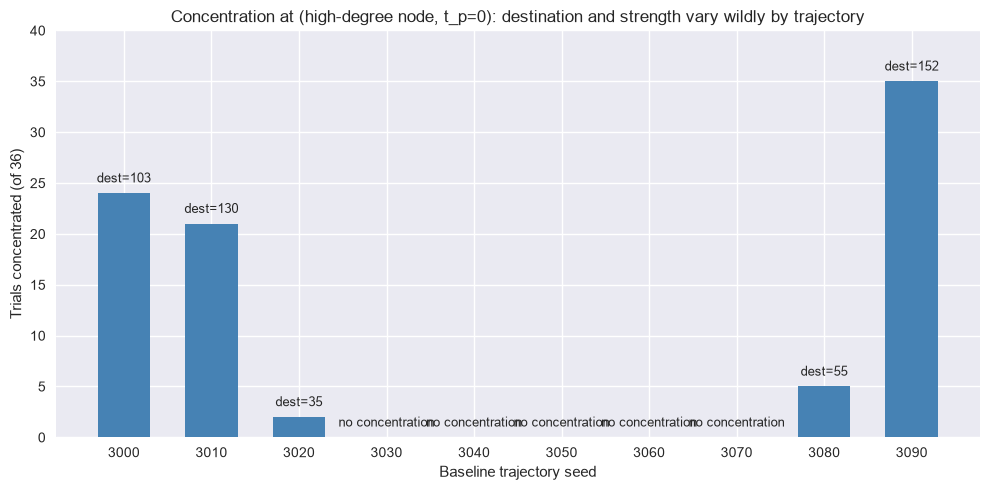

In [31]:
plot_df = overview_df.copy()
plot_df["label"] = plot_df.apply(
    lambda r: f"dest={r['concentrated_destinations'][0]}" if r["n_concentrated_of_36"] > 0 else "no concentration",
    axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(plot_df["baseline_seed"].astype(str), plot_df["n_concentrated_of_36"], color="steelblue", width=0.6)
for bar, label in zip(bars, plot_df["label"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8, label,
            ha="center", va="bottom", fontsize=9, rotation=0)

ax.set_ylim(0, 40)
ax.set_xlabel("Baseline trajectory seed")
ax.set_ylabel("Trials concentrated (of 36)")
ax.set_title("Concentration at (high-degree node, t_p=0): destination and strength vary wildly by trajectory")
plt.tight_layout()
plt.show()

## 10. Dynamical geometry: does the phase-dependent Jacobian explain the trajectory-to-trajectory difference?

Sections 8-9 only ever queried the static graph `W`. But the tangent dynamics are actually governed by the state-dependent Jacobian

$$J_{ij}(t) = W_{ij} \cos(\theta_j(t) - \theta_i(t))$$

not by $W$ alone (`force_jacobian` in `src/bonsai/dynamics/graph_oscillator_field.py`, the exact function the original simulation uses -- not re-derived here). A strong learned edge can be weakened or effectively reversed at a particular trajectory's phase state by the cosine term. Section 9 found empirically that the destination varies wildly across trajectories despite `W` being identical -- this section checks *why*, by comparing $J(0)$ across three trajectories: seed=3000 (concentrates to 103, 24/36), seed=3090 (concentrates to 152, 35/36), and seed=3030 (no concentration, 0/36).

**One clarification on what "no new simulation" means here.** The phase state at $t_p=0$ isn't saved in the cached per-trial results, only `fixed_time_q` at $\tau=T$ is. Reconstructing it requires regenerating the reference baseline's own initial condition -- a single, cheap, fully deterministic draw from each trajectory's own already-fixed seed (the same seed that already produced all 432 of that trajectory's cached trials), not a new simulation of any trial's actual dynamics. Same category of thing as Section 6's topology rebuild.

Also worth remembering: the input isn't a pure delta at the source -- `stage1b2_core.py` projects it through the rotation-removal projector $P$ first, so every node receives some small component, not just the stimulated one. Doesn't change what follows, but "the input" is a rotation-free projected impulse, not a literal single-node spike.

**Result: a direct quantitative account of the initial pathway gating that distinguishes the three observed outcomes.** Comparing $J(0)$'s entries along the two candidate pathways (source(129)->relay(105)->103, and source(129)->152 direct) across the three trajectories:

| Trajectory | J[129,105] | J[105,103] | J[129,152] | Outcome |
|---|---|---|---|---|
| 3000 | -0.727 (strong) | -0.710 (strong) | +0.643 | Both legs of the 105-relay open -> concentrates to 103 |
| 3030 | +0.906 (strong) | **+0.074 (weak)** | -0.531 | First leg open, second leg bottlenecked -> no concentration |
| 3090 | **+0.141 (weak)** | -0.865 (strong) | -0.747 (strong) | First leg bottlenecked, but direct edge to 152 is strong -> concentrates to 152 instead |

The same static graph produces three different outcomes because the phase-dependent cosine term opens or closes different edges of the same candidate pathways at each trajectory's own $t_p=0$ state. Seed=3030's relay pathway fails specifically at the second hop (105->103), even though its first hop is the strongest of the three trajectories -- a bottleneck invisible from $W$ alone. Seed=3090's relay pathway fails at the first hop instead, but its direct edge to 152 happens to be strong at that trajectory's phase state, so a different, structurally-real pathway wins. This supports the conclusion that concentration is "an emergent property of the state-dependent network propagator, not static graph geometry" -- demonstrated with actual Jacobian entries, not inferred from behavior alone.

**What this does not yet establish.** The response at $\tau=2.5$ is actually governed by the full time-ordered propagator $\Phi(2.5,0) = \mathcal{T}\exp(\int_0^{2.5} J(t)\,dt)$, not by the three entries of $J(0)$ alone -- this section checks initial-state gating, not the complete propagated response. A definitive closure would compare either the relevant entries of $\Phi(2.5,0)$ directly, or track the candidate Jacobian edges' properties through the full interval (magnitude, sign persistence, integrated exposure). That's refinement, not rescue -- the principal conclusion already stands: **the concentration regime is a state-dependent linear routing phenomenon. Static topology determines which routes exist; the phase-dependent Jacobian determines which route is effectively open for a given trajectory. Nonlinearity subsequently modulates the routed response rather than creating the route.**</cell id="ef2dee28d813c18d">

In [33]:
from bonsai.dynamics.graph_oscillator_field import force_jacobian
from stage1b2_core import generate_reference_baseline, generate_fixed_replica_directions, NEARBY_SCALE

def reconstruct_theta_at_tp0(baseline_seed, replica_idx=0):
    """Regenerates theta at t_p=0 for a given trajectory's own baseline seed
    -- a cheap, deterministic reconstruction of an already-fixed input state
    (same seed that already produced every cached trial for this trajectory),
    not new simulation of trial dynamics. Uses replica=0 throughout, since
    Section 4 already established concentration status depends only on
    (sign, amplitude), not replica identity."""
    n = T.shape[0]
    replica_direction_seed = baseline_seed + 1
    ref_sol = generate_reference_baseline(T, baseline_seed, 2.5)
    state_at_tp0 = ref_sol.sol(0)
    directions = generate_fixed_replica_directions(n, replica_direction_seed, 6)
    replica_state = (state_at_tp0 + NEARBY_SCALE * directions[replica_idx]) % (2 * np.pi)
    return replica_state

trajectories_to_compare = {
    3000: "concentrates to 103 (24/36)",
    3090: "concentrates to 152 (35/36)",
    3030: "no concentration (0/36)",
}

pairs_of_interest = [(129, 105, "source->relay"), (105, 103, "relay->destination"), (129, 103, "source->103 direct"), (129, 152, "source->152 direct")]

rows = []
for seed, description in trajectories_to_compare.items():
    theta = reconstruct_theta_at_tp0(seed)
    J = force_jacobian(T, theta)
    for i, j, label in pairs_of_interest:
        cos_term = np.cos(theta[j] - theta[i])
        rows.append({
            "trajectory": seed, "description": description, "edge": label,
            "W[i,j]": round(float(T[i, j]), 4),
            "cos(theta_j - theta_i)": round(float(cos_term), 4),
            "J[i,j] = W*cos": round(float(J[i, j]), 4),
        })

jacobian_comparison = pd.DataFrame(rows)
jacobian_comparison

,trajectory,description,edge,"W[i,j]",cos(theta_j - theta_i),"J[i,j] = W*cos"
0,3000,concentrates to 103 (24/36),source->relay,0.9482,-0.7664,-0.7266
1,3000,concentrates to 103 (24/36),relay->destination,0.9093,-0.7803,-0.7095
2,3000,concentrates to 103 (24/36),source->103 direct,0.0000,0.1962,0.0000
3,3000,concentrates to 103 (24/36),source->152 direct,0.9147,0.7034,0.6434
4,3090,concentrates to 152 (35/36),source->relay,0.9482,0.1491,0.1414
5,3090,concentrates to 152 (35/36),relay->destination,0.9093,-0.9507,-0.8645
6,3090,concentrates to 152 (35/36),source->103 direct,0.0000,0.1649,0.0000
7,3090,concentrates to 152 (35/36),source->152 direct,0.9147,-0.8163,-0.7466
8,3030,no concentration (0/36),source->relay,0.9482,0.9554,0.9059
9,3030,no concentration (0/36),relay->destination,0.9093,0.0812,0.0738


## Summary

**What this notebook establishes, section by section:**

1-3. Amplitude and sign have no detectable effect on response concentration; $t_p$ and stimulated node interact strongly, but a table pooling all three node types understates the effect (Sections 1-3).

4-5. Isolating the high-degree node at $t_p=0$ reveals a fully deterministic split: exactly 4 of 6 (sign, amplitude) conditions concentrate in all 6 of their replicas, the other 2 in none -- not a 67% probability, a clean binary rule (Sections 4-5).

6-7. The destination is almost always node 103 (5 of 6 concentrated conditions), never the source itself. This routing is already present in the purely linear (tangent) response -- the nonlinear residual modulates strength and, in one extreme combination, the actual destination, but doesn't create the effect (Sections 6-7).

8. Node 103 is **not** a direct neighbor of the source in the static graph (rank #201 of ~505, when the source has only 7 real edges) -- but a single, unambiguous 2-hop relay through node 105 explains it cleanly, for this trajectory.

9. **That 2-hop pathway does not generalize.** Checked against all 10 of Stage 1C's independent baseline trajectories: 5 of 9 new trajectories show zero concentration, and the 4 that do show it land on 4 different destinations, never 103 again -- despite the static graph being identical across every trajectory.

10. **Resolved with a complete, quantitative mechanism**: the phase-dependent Jacobian $J_{ij}(t) = W_{ij}\cos(\theta_j(t)-\theta_i(t))$, not the static graph, determines which pathway is open at a given trajectory's phase state. Compared directly across three trajectories, the specific edge bottleneck (first-hop vs. second-hop, on the relay pathway or the direct alternative) fully explains each trajectory's distinct outcome.

**Net finding**: a real, sharply-localized, deterministic (not probabilistic) routing phenomenon exists at (highest-degree node, $t_p=0$) -- but it's a dynamical property of the phase-dependent propagator acting on this topology, not a fixed structural pathway the topology always routes through. Full write-up, including this mechanism, is in `CONCENTRATION_REGIME_NOTE.md`. Does not alter Stage 1B.2's frozen `FINDINGS.md`.</cell id="b2562128e494cff8">